In [9]:
import os
import sys

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [10]:
TRAIN_DIR = 'artifacts/data/car_images/training' 
VAL_DIR = 'artifacts/data/car_images/validation'

# Image Parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Generators: This will do augmentation too (Rotate, Zoom) so model can become Robust
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values (0-255 to 0-1)
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'binary' # Damaged (0) or Whole (1)
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(f"Classes: {train_generator.class_indices}")


Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
Classes: {'00-damage': 0, '01-whole': 1}


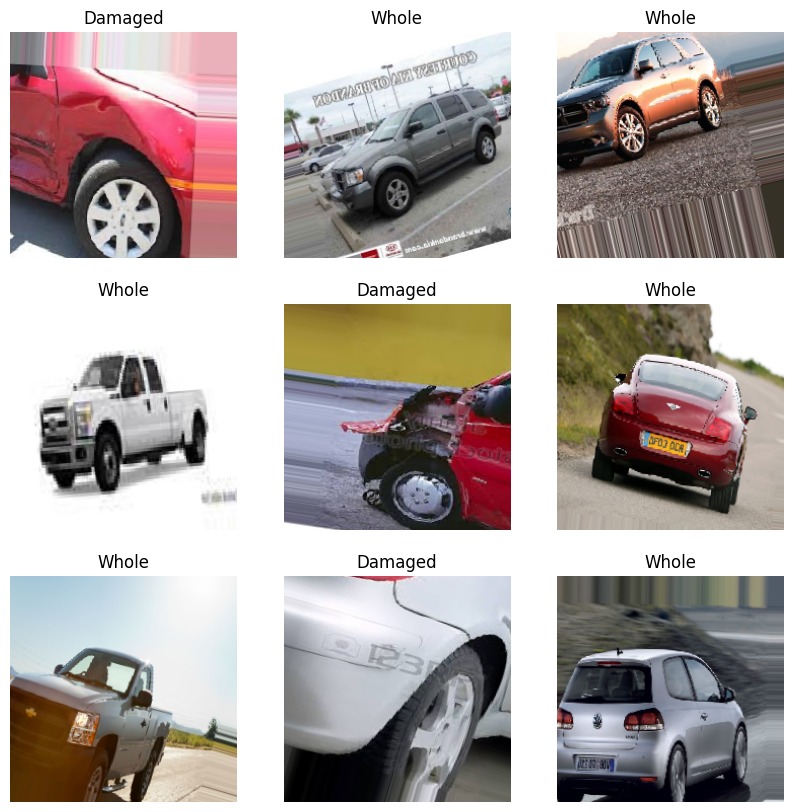

In [ ]:
# Get 1 batch 
imgs, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imgs[i])
    status = "Whole" if labels[i] == 1 else "Damaged" # Label adjust karna padega indices ke hisab se
    plt.title(status)
    plt.axis("off")
plt.show()


In [12]:
model = Sequential()

# Layer 1: Convolution
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(MaxPooling2D(2,2))

# Layer 2: Convolution
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Layer 3: Convolution
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten: 2D image map's to 1D array
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # Stop Overfitting
model.add(Dense(1, activation='sigmoid')) # Binary Classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)


Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 44s 740ms/step - accuracy: 0.5413 - loss: 0.7241 - val_accuracy: 0.5935 - val_loss: 0.6777
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 698ms/step - accuracy: 0.6196 - loss: 0.6690 - val_accuracy: 0.6370 - val_loss: 0.6430
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 722ms/step - accuracy: 0.6413 - loss: 0.6443 - val_accuracy: 0.6696 - val_loss: 0.6520
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 735ms/step - accuracy: 0.6712 - loss: 0.6332 - val_accuracy: 0.6326 - val_loss: 0.6366
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 51s 880ms/step - accuracy: 0.6815 - loss: 0.6045 - val_accuracy: 0.7087 - val_loss: 0.5892
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 776ms/step - accuracy: 0.6897 - loss: 0.5950 - val_accuracy: 0.7370 - val_loss: 0.5507
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 827ms/step - accuracy: 0.6978 - loss: 0.5968 - val_accuracy: 0.7370 - val_loss: 0.5479
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 47s 803ms/step - accuracy: 0.7022 - loss: 0.5805 - val_accu

In [14]:
import os
from src.constants import CNN_MODEL_PATH
model_path = CNN_MODEL_PATH
model.save(model_path)
print(f"Model Saved at: {model_path}")


Model Saved at: artifacts/models/cnn_model.keras
